In [1]:
import sys
sys.path.append('..')

from ontology_handling import TreeHelper
from dharani_functions import DharaniHelper
from annotation_handling import get_properties


In [2]:
helper = DharaniHelper(specimennum=2, downsample=0)

In [3]:
print(helper)

Dharani_Specimen_2, downsample=0


In [4]:
len(helper.get_section_numbers())

536

In [5]:
secnames = helper.get_filenames()

In [6]:
secnames

{1: {'image': 'Specimen_2_1.tif'},
 10: {'image': 'Specimen_2_10.tif'},
 1000: {'image': 'Specimen_2_1000.tif', 'annotation': 'Specimen_2_1000.json'},
 1003: {'image': 'Specimen_2_1003.tif'},
 1006: {'image': 'Specimen_2_1006.tif'},
 1009: {'image': 'Specimen_2_1009.tif'},
 1012: {'image': 'Specimen_2_1012.tif'},
 1015: {'image': 'Specimen_2_1015.tif', 'annotation': 'Specimen_2_1015.json'},
 1018: {'image': 'Specimen_2_1018.tif'},
 1021: {'image': 'Specimen_2_1021.tif'},
 1024: {'image': 'Specimen_2_1024.tif'},
 1027: {'image': 'Specimen_2_1027.tif'},
 103: {'image': 'Specimen_2_103.tif'},
 1030: {'image': 'Specimen_2_1030.tif'},
 1033: {'image': 'Specimen_2_1033.tif', 'annotation': 'Specimen_2_1033.json'},
 1036: {'image': 'Specimen_2_1036.tif'},
 1039: {'image': 'Specimen_2_1039.tif'},
 1042: {'image': 'Specimen_2_1042.tif', 'annotation': 'Specimen_2_1042.json'},
 1045: {'image': 'Specimen_2_1045.tif'},
 1048: {'image': 'Specimen_2_1048.tif'},
 1051: {'image': 'Specimen_2_1051.tif'},

## Get the annotation data
get_annotation creates shapely geometries, which can be used to get properties

In [7]:
annotations_by_ontoid = helper.get_annotations()

sec 250 - skipped 117 : geomtype LineString
sec 256 - skipped 117 : geomtype LineString
sec 268 - skipped 117 : geomtype LineString
sec 277 - skipped 117 : geomtype LineString
sec 280 - skipped 117 : geomtype LineString
sec 283 - skipped 117 : geomtype LineString
sec 439 - skipped 44 : too few coordinates (2, 2)
sec 439 - skipped 41 : too few coordinates (2, 2)
sec 439 - skipped 42 : too few coordinates (2, 2)
sec 439 - skipped 19 : too few coordinates (2, 2)
sec 439 - skipped 36 : too few coordinates (2, 2)
sec 439 - skipped 43 : too few coordinates (3, 2)
sec 439 - skipped 42 : too few coordinates (3, 2)
sec 499 - skipped 296 : too few coordinates (3, 2)
sec 619 - skipped 46 : geomtype LineString
sec 625 - skipped 46 : geomtype LineString
sec 634 - skipped 46 : geomtype LineString
sec 652 - skipped 46 : geomtype LineString
sec 652 - skipped 128 : geomtype LineString
sec 667 - skipped 46 : geomtype LineString
sec 667 - skipped 128 : geomtype LineString
sec 682 - skipped 46 : geomtype 

## organize the annotations to get counts, areas etc

In [9]:
from collections import defaultdict

In [12]:
from matplotlib import pyplot as plt
import numpy as np

In [13]:
sections = set()
cntlist  = defaultdict(dict)

for oid in annotations_by_ontoid:
    seclist = sorted(list(annotations_by_ontoid[oid].keys()))
    sections=sections.union(set(seclist))
    for sec in seclist:
        geom = annotations_by_ontoid[oid][sec]
        if geom.geom_type=='MultiPolygon':
            cnt = len(geom.geoms)
        else:
            cnt = 1
        cntlist[sec][oid]=cnt

Text(0.5, 1.0, 'number of annotated polygons, against section number')

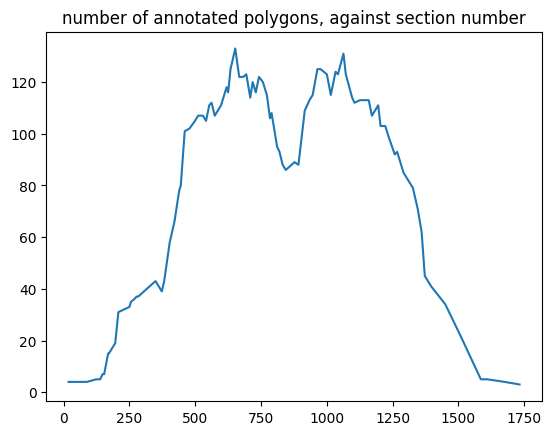

In [14]:
X = sorted(cntlist.keys())
Y = [len(cntlist[x]) for x in X]
plt.plot(X,Y)
plt.title('number of annotated polygons, against section number')

Text(0.5, 1.0, 'gap to next annotated section, against section number')

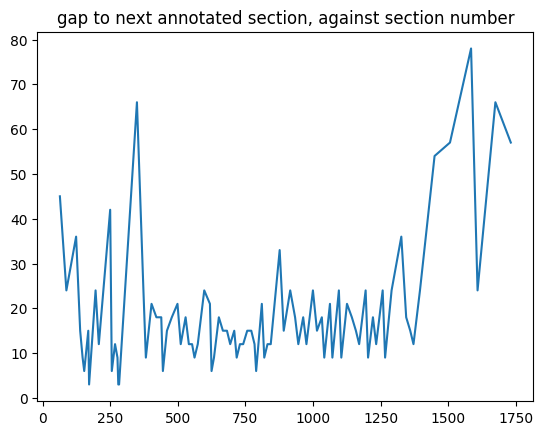

In [15]:
plt.plot(X[1:],np.diff(X))
plt.title('gap to next annotated section, against section number')

In [16]:
np.mean(np.diff(X)), np.median(np.diff(X))

(19.247191011235955, 15.0)

In [17]:
len(sections)

90

View the annotated ontoids by section number

In [18]:
cntlist

defaultdict(dict,
            {19: {51: 1, 49: 1, 48: 1, 50: 1},
             64: {51: 1, 49: 2, 48: 2, 50: 1},
             88: {51: 1, 49: 1, 48: 3, 50: 1},
             124: {51: 1, 49: 1, 48: 2, 50: 1, 52: 1},
             139: {51: 1, 49: 1, 48: 1, 50: 1, 52: 1},
             148: {51: 1, 49: 1, 48: 1, 50: 1, 52: 1, 502: 1, 501: 1},
             154: {51: 1, 49: 1, 48: 1, 50: 1, 52: 1, 502: 1, 501: 1},
             169: {51: 1,
              49: 1,
              48: 3,
              50: 1,
              52: 1,
              502: 1,
              501: 1,
              504: 1,
              31: 1,
              32: 1,
              33: 1,
              13: 1,
              15: 1,
              14: 1,
              503: 1},
             172: {51: 1,
              49: 1,
              48: 2,
              50: 1,
              52: 1,
              502: 1,
              501: 1,
              504: 1,
              31: 1,
              32: 1,
              33: 1,
              13: 1,
    

In [19]:
# annot_err = helper.get_annotation(439) # specimen 

In [20]:
# type(annot_err[42])

Lookup the skipped ids (these don't seem to be polygons)

In [21]:
dharani_onto_helper = TreeHelper('dharani')

In [22]:
dharani_onto_helper.onto_lookup[19]

NodeRecord(acronym='VZ-FCTx', name='Ventricular zone, frontal cortex', color_hex_triplet='#e670be', level=5, parentid=12, numchildren=0)

In [23]:
dharani_onto_helper.onto_lookup[117]

NodeRecord(acronym='LF', name='Lateral fissure', color_hex_triplet='#CFE4C2', level=4, parentid=4, numchildren=0)

In [24]:
dharani_onto_helper.onto_lookup[46]

NodeRecord(acronym='CaS', name='Calcarine sulcus', color_hex_triplet='#CFE4C2', level=4, parentid=4, numchildren=0)

Print all annotated structure names in this specimen (show the full name, and list of sections for each structure) 

In [25]:
for oid in annotations_by_ontoid:
    seclist = sorted(list(annotations_by_ontoid[oid].keys()))
    if len(seclist)>0:
        print(oid, dharani_onto_helper.get_full_name_by_ontoid(oid),seclist)

51 ('Brain/Forebrain/Telencephalon/Cerebral cortex/Temporal cortex', 'Br/FB/Tel/Ctx/TEMP', 'Subplate zone, temporal cortex', 'SP-TEMP') [19, 64, 88, 124, 139, 148, 154, 169, 172, 196, 208, 250, 256, 268, 277, 280, 283, 349, 373, 382, 403, 421, 439, 445, 460, 478, 1327, 1345, 1360, 1372, 1396, 1450, 1507, 1585, 1609, 1675]
49 ('Brain/Forebrain/Telencephalon/Cerebral cortex/Temporal cortex', 'Br/FB/Tel/Ctx/TEMP', 'Marginal zone, temporal cortex', 'MZ-TEMP') [19, 64, 88, 124, 139, 148, 154, 169, 172, 196, 208, 250, 256, 268, 277, 280, 283, 349, 373, 382, 403, 421, 439, 445, 460, 478, 1327, 1345, 1360, 1372, 1396, 1450, 1507, 1585, 1609, 1675, 1732]
48 ('Brain/Forebrain/Telencephalon/Cerebral cortex/Temporal cortex', 'Br/FB/Tel/Ctx/TEMP', 'Subpial granular layer, temporal cortex', 'SGL-TEMP') [19, 64, 88, 124, 139, 148, 154, 169, 172, 196, 208, 250, 256, 268, 277, 280, 283, 349, 373, 382, 403, 421, 439, 445, 460, 478, 1327, 1345, 1360, 1372, 1396, 1450, 1507, 1585, 1609, 1675, 1732]
50 ('B

KeyError: 470

Find the `ontoid` of Thalamus and temporal cortex, using `dharani_onto_helper`

In [26]:
search_str = 'temporal' # 'Thalamus'
dharani_onto_helper.search(search_str, partial=True)

[SearchResult(matched_name='temporal cortex', score=100.0, ontoid=47),
 SearchResult(matched_name='subpial granular layer, temporal cortex', score=100.0, ontoid=48),
 SearchResult(matched_name='marginal zone, temporal cortex', score=100.0, ontoid=49),
 SearchResult(matched_name='cortical plate, temporal cortex', score=100.0, ontoid=50),
 SearchResult(matched_name='subplate zone, temporal cortex', score=100.0, ontoid=51)]

Find successors of Thalamus (or Temporal Cortex), defined in the ontology

In [27]:
resid=47 # 160
search_successors=dharani_onto_helper.get_successor_ids(resid)

In [28]:
for ch_id in search_successors:
    print(ch_id, dharani_onto_helper.get_full_name_by_ontoid(ch_id))

48 ('Brain/Forebrain/Telencephalon/Cerebral cortex/Temporal cortex', 'Br/FB/Tel/Ctx/TEMP', 'Subpial granular layer, temporal cortex', 'SGL-TEMP')
49 ('Brain/Forebrain/Telencephalon/Cerebral cortex/Temporal cortex', 'Br/FB/Tel/Ctx/TEMP', 'Marginal zone, temporal cortex', 'MZ-TEMP')
50 ('Brain/Forebrain/Telencephalon/Cerebral cortex/Temporal cortex', 'Br/FB/Tel/Ctx/TEMP', 'Cortical plate, temporal cortex', 'CP-TEMP')
51 ('Brain/Forebrain/Telencephalon/Cerebral cortex/Temporal cortex', 'Br/FB/Tel/Ctx/TEMP', 'Subplate zone, temporal cortex', 'SP-TEMP')
52 ('Brain/Forebrain/Telencephalon/Cerebral cortex/Temporal cortex', 'Br/FB/Tel/Ctx/TEMP', 'Intermediate zone, temporal cortex', 'IZ-TEMP')
53 ('Brain/Forebrain/Telencephalon/Cerebral cortex/Temporal cortex', 'Br/FB/Tel/Ctx/TEMP', 'Subventricular zone, temporal cortex', 'SVZ-TEMP')
54 ('Brain/Forebrain/Telencephalon/Cerebral cortex/Temporal cortex', 'Br/FB/Tel/Ctx/TEMP', 'Ventricular zone, temporal cortex', 'VZ-TEMP')


Find these in the annotations; map from secno to dict of ontoid:geometry

In [29]:
search_annotations = defaultdict(dict)

for ch in [resid]+search_successors:
    if ch in annotations_by_ontoid:
        for secno in annotations_by_ontoid[ch]:
            search_annotations[secno][ch]=annotations_by_ontoid[ch][secno]
        

the 2d equivalent of the above block is in nb_functions.py `display_annotation` with ontoids passed. Here we are doing it for the whole brain

In [30]:
X = [] # section numbers
Y = [] # number of thalamic annotations

for secno in sorted(search_annotations):
    X.append(secno)
    print(secno, search_annotations[secno].keys())
    Y.append(len(search_annotations[secno].keys()))

19 dict_keys([48, 49, 50, 51])
64 dict_keys([48, 49, 50, 51])
88 dict_keys([48, 49, 50, 51])
124 dict_keys([48, 49, 50, 51, 52])
139 dict_keys([48, 49, 50, 51, 52])
148 dict_keys([48, 49, 50, 51, 52])
154 dict_keys([48, 49, 50, 51, 52])
169 dict_keys([48, 49, 50, 51, 52])
172 dict_keys([48, 49, 50, 51, 52])
196 dict_keys([48, 49, 50, 51, 52, 53])
208 dict_keys([48, 49, 50, 51, 52, 53, 54])
250 dict_keys([48, 49, 50, 51, 52, 53, 54])
256 dict_keys([48, 49, 50, 51, 52, 53, 54])
268 dict_keys([48, 49, 50, 51, 52, 53, 54])
277 dict_keys([48, 49, 50, 51, 52, 53, 54])
280 dict_keys([48, 49, 50, 51, 52, 53, 54])
283 dict_keys([48, 49, 50, 51, 52, 53, 54])
349 dict_keys([48, 49, 50, 51, 52, 53, 54])
373 dict_keys([48, 49, 50, 51, 52, 53, 54])
382 dict_keys([48, 49, 50, 51, 52, 53, 54])
403 dict_keys([48, 49, 50, 51, 52, 53, 54])
421 dict_keys([48, 49, 50, 51, 52, 53, 54])
439 dict_keys([48, 49, 50, 51, 52, 53, 54])
445 dict_keys([48, 49, 50, 51, 52, 53, 54])
460 dict_keys([48, 49, 50, 51, 52, 

Text(0.5, 1.0, 'number of `temporal` annotations, against section number')

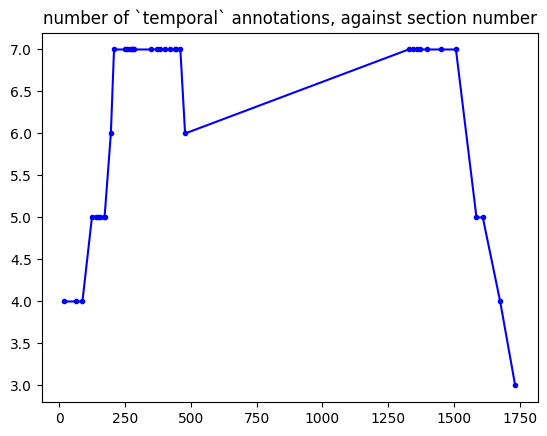

In [31]:
plt.plot(X,Y,'b.-')
plt.title(f'number of `{search_str}` annotations, against section number')

In [32]:
secno = 250 # 985 # 589

for ontoid in search_annotations[secno]:
    shp = search_annotations[secno][ontoid]
    
    print(ontoid, dharani_onto_helper.onto_lookup[ontoid])
    props = get_properties(shp)
    print(props)

48 NodeRecord(acronym='SGL-TEMP', name='Subpial granular layer, temporal cortex', color_hex_triplet='#b8a98a', level=5, parentid=47, numchildren=0)
{'pt': (29911.510266420384, 45681.44897217518), 'area': 2115052.790544739, 'perimeter': 45149.267153678666, 'numcomp': 4, 'bbox': (18887.631314841252, 37343.475995849585, 34499.938253615466, 45929.19559092248), 'aspectratio': 2.457282838464164, 'obb': <POLYGON ((36290.291 43471.846, 21134.585 49022.528, 18875.715 42854.86, 340...>, 'majoraxislength': 16140.182658109708, 'minoraxislength': 6568.304798074261, 'maxwidth': 77.84559282616561, 'orientation': -20.114938362947388}
49 NodeRecord(acronym='MZ-TEMP', name='Marginal zone, temporal cortex', color_hex_triplet='#de895e', level=5, parentid=47, numchildren=0)
{'pt': (16145.406725529077, 40487.580564309756), 'area': 4534040.727403722, 'perimeter': 58220.95891236912, 'numcomp': 1, 'bbox': (15679.40849258341, 35071.11861974266, 34385.91552534385, 45836.65026239039), 'aspectratio': 1.94230828338

Get areas

In [33]:

X = [] # section numbers
Y = [] # area of thalamic annotations

for secno in sorted(search_annotations):
    X.append(secno)
    print(secno,search_annotations[secno].keys())
    ar_sec = 0
    for ontoid in search_annotations[secno]:
        shp = search_annotations[secno][ontoid]
        props = get_properties(shp)
        ar_sec+=props['area']
    Y.append(ar_sec)

19 dict_keys([48, 49, 50, 51])
64 dict_keys([48, 49, 50, 51])
88 dict_keys([48, 49, 50, 51])
124 dict_keys([48, 49, 50, 51, 52])
139 dict_keys([48, 49, 50, 51, 52])
148 dict_keys([48, 49, 50, 51, 52])
154 dict_keys([48, 49, 50, 51, 52])
169 dict_keys([48, 49, 50, 51, 52])
172 dict_keys([48, 49, 50, 51, 52])
196 dict_keys([48, 49, 50, 51, 52, 53])
208 dict_keys([48, 49, 50, 51, 52, 53, 54])
250 dict_keys([48, 49, 50, 51, 52, 53, 54])
256 dict_keys([48, 49, 50, 51, 52, 53, 54])
268 dict_keys([48, 49, 50, 51, 52, 53, 54])
277 dict_keys([48, 49, 50, 51, 52, 53, 54])
280 dict_keys([48, 49, 50, 51, 52, 53, 54])
283 dict_keys([48, 49, 50, 51, 52, 53, 54])
349 dict_keys([48, 49, 50, 51, 52, 53, 54])
373 dict_keys([48, 49, 50, 51, 52, 53, 54])
382 dict_keys([48, 49, 50, 51, 52, 53, 54])
403 dict_keys([48, 49, 50, 51, 52, 53, 54])
421 dict_keys([48, 49, 50, 51, 52, 53, 54])
439 dict_keys([48, 49, 50, 51, 52, 53, 54])
445 dict_keys([48, 49, 50, 51, 52, 53, 54])
460 dict_keys([48, 49, 50, 51, 52, 

Text(0.5, 1.0, 'area of `temporal` annotated, against section number')

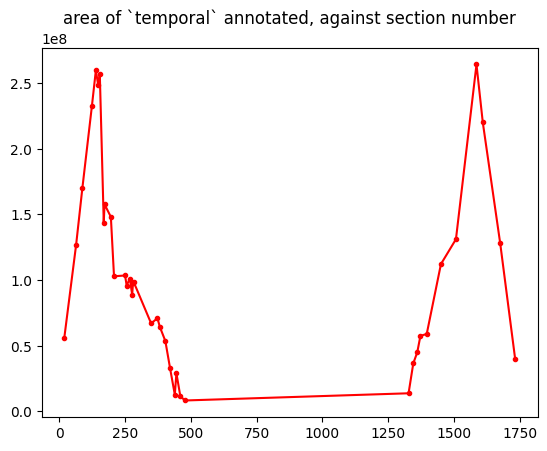

In [34]:
plt.plot(X,Y,'r.-')
plt.title(f'area of `{search_str}` annotated, against section number')

In [35]:
mid=(max(sections)+min(sections))//2

In [36]:
mid

875

In [37]:
split_pos = np.where(np.array(X)<mid)[0].max()+1

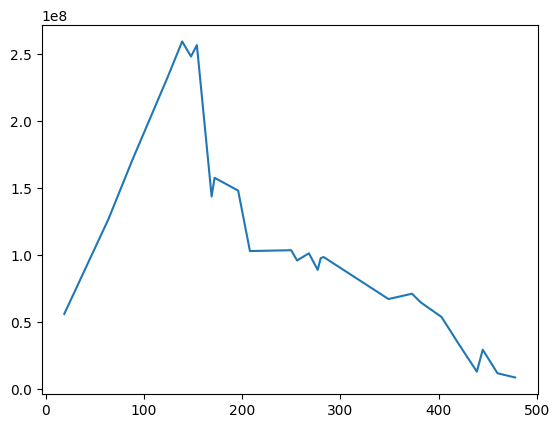

In [38]:
plt.plot(X[:split_pos],Y[:split_pos])

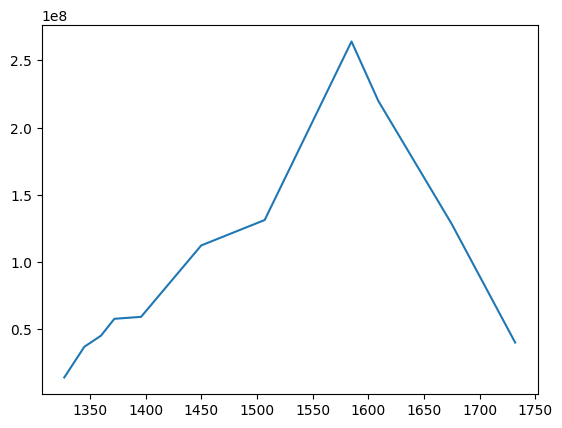

In [39]:
plt.plot(X[split_pos:],Y[split_pos:])

In [40]:
v_left=np.trapz(Y[:split_pos],X[:split_pos])

In [41]:
v_right=np.trapz(Y[split_pos:],X[split_pos:])

In [42]:
v_left/v_right

0.9466919210377777

in mm^3; @1mpp, 1pix = 1umsq = 10^-6mmsq; section thickness is 20um = 0.02mm; vol of 1 pix is 0.02*10^-6 mm3 

In [48]:
v_left*(10**-6)*0.02, v_right*(10**-6)*0.02

(987.0797810924851, 1042.6620943489552)

In [54]:
## cumulative sums - these seem to be misleading and uninformative

In [50]:
Y_left=np.cumsum(Y[:split_pos])
Y_right = np.cumsum(Y[split_pos:])

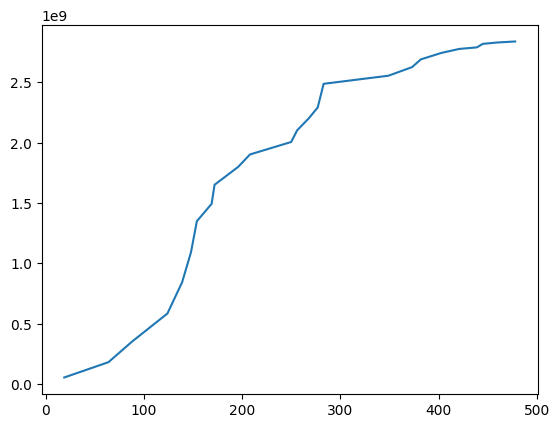

In [51]:
plt.plot(X[:split_pos],Y_left)

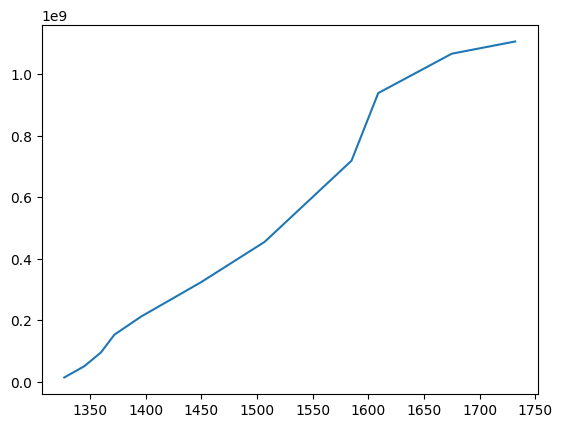

In [52]:
plt.plot(X[split_pos:],Y_right)